In [1]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

  Cloning https://github.com/NetManAIOps/sktime.git to /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr0000gn/T/pip-req-build-d4x3z67_
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr0000gn/T/pip-req-build-d4x3z67_
  error: RPC failed; curl 28 Failed to connect to github.com port 443 after 75001 ms: Couldn't connect to server
  fatal: expected flush after ref listing
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr0000gn/T/pip-req-build-d4x3z67_ did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr

# STL forecasting with sktime

This notebook demonstrates **STL** (Seasonal-Trend decomposition using Loess): decompose the series into **trend, seasonal, and residual**, fit a forecaster to each component, then sum the point forecasts. The implementation is `sktime.forecasting.trend.STLForecaster`, which wraps `statsmodels` STL.

## 1. Data and train / test split

Classic monthly airline passengers; seasonal period `sp=12`. The series uses a pandas `PeriodIndex`; we keep it for sktime forecasters and only convert to timestamps in plots (see `_mpl_time_index` in the next cell).

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import mean_absolute_error

# Classic univariate benchmark series (monthly); keep PeriodIndex for sktime (Naive/sp).
y = load_airline()
# Hold-out split by index position (not random shuffle).
split_point = int(len(y) * 0.8)
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]
fh = ForecastingHorizon(y_test.index, is_relative=False)


def _mpl_time_index(index):
    """Matplotlib x-axis: PeriodIndex -> timestamps (do not mutate y for forecasting)."""
    if isinstance(index, pd.PeriodIndex):
        return index.to_timestamp(how="start")
    return index


print(f"Train length: {len(y_train)}, Test length: {len(y_test)}")
y_train.head()

Train length: 115, Test length: 29


Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

## 2. `STLForecaster`: decomposition + default component forecasters

- **Trend**: `NaiveForecaster(strategy="drift")`
- **Seasonal**: `NaiveForecaster(sp=..., strategy="last")`
- **Residual**: `NaiveForecaster(sp=..., strategy="mean")`

At predict time, point forecasts from the three components are added. Parameters such as `seasonal` and `trend` are passed through to `statsmodels` STL smoothers (odd lengths; default `seasonal=7`).

**STL forecast pipeline**

1. **Decompose (`fit`)** — `statsmodels.tsa.seasonal.STL` splits `y_train` into `trend_`, `seasonal_`, and `resid_` (same index as `y_train`).
2. **Fit component forecasters (`fit`)** — clones of the trend / seasonal / residual forecasters are fitted to each component series (with the same `X` and `fh` passed to `STLForecaster.fit`).
3. **Predict (`predict`)** — each fitted sub-forecaster predicts the horizon `fh` on its component.
4. **Recompose (`predict`)** — the final forecast is the **sum** of the three component point forecasts (same index as `fh`).

In [12]:
from sktime.forecasting.trend import STLForecaster

sp = 12
# seasonal must be odd for statsmodels STL; > period is often reasonable.
stl_fcst = STLForecaster(sp=sp, seasonal=13)
stl_fcst.fit(y_train, fh=fh)

y_pred_stl = stl_fcst.predict(fh)
mae_stl = mean_absolute_error(y_test, y_pred_stl)
print(f"STLForecaster MAE: {mae_stl:.3f}")

STLForecaster MAE: 32.038


## 3. STL decomposition on the training set (trend / seasonal / residual)

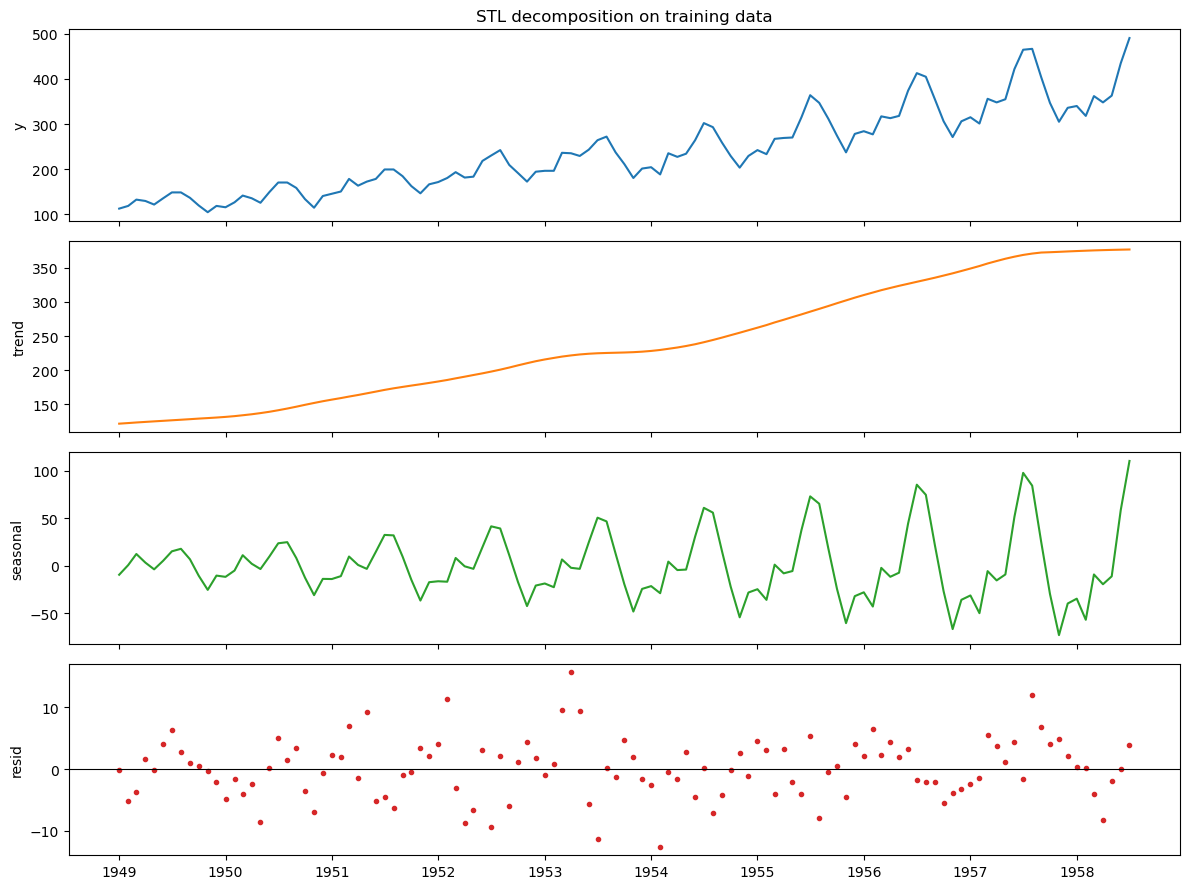

In [13]:
# Fitted attributes: trend_, seasonal_, resid_ (training index only).
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 9))
axes[0].plot(_mpl_time_index(y_train.index), y_train.values, color="C0")
axes[0].set_ylabel("y")
axes[0].set_title("STL decomposition on training data")
axes[1].plot(_mpl_time_index(stl_fcst.trend_.index), stl_fcst.trend_.values, color="C1")
axes[1].set_ylabel("trend")
axes[2].plot(_mpl_time_index(stl_fcst.seasonal_.index), stl_fcst.seasonal_.values, color="C2")
axes[2].set_ylabel("seasonal")
axes[3].plot(_mpl_time_index(stl_fcst.resid_.index), stl_fcst.resid_.values, color="C3", marker=".", linestyle="None")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("resid")
plt.tight_layout()
plt.show()

## 4. Hold-out forecast

Plot train, test, and STL forecasts on the hold-out window. **MAE** is computed on the test segment.

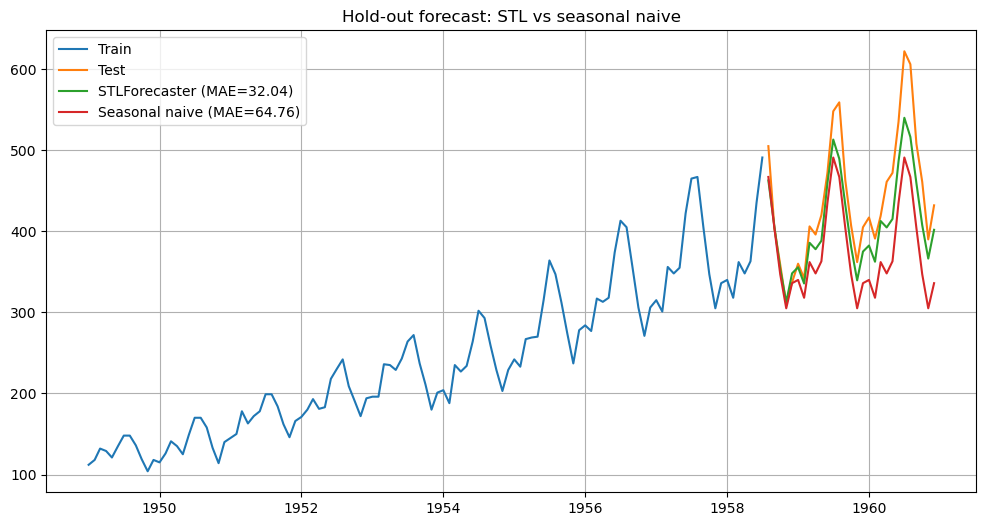

MAE - STLForecaster: 32.0384
MAE - Seasonal naive: 64.7586


In [14]:
plt.figure(figsize=(12, 6))
plt.plot(_mpl_time_index(y_train.index), y_train.values, label="Train")
plt.plot(_mpl_time_index(y_test.index), y_test.values, label="Test")
plt.plot(_mpl_time_index(y_pred_stl.index), y_pred_stl.values, label=f"STLForecaster (MAE={mae_stl:.2f})")
plt.title("Hold-out forecast (STLForecaster)")
plt.legend()
plt.grid(True)
plt.show()

print(f"MAE - STLForecaster: {mae_stl:.4f}")

## 5. (Optional) Custom forecasters per component

Example: Holt linear trend (`ExponentialSmoothing`) for the trend component only; other components use defaults.